# Deep Learning Project
## Traffic Sign Recognition

Author: Natty Martinez

## Project Scenario
We are AI Engineers at DriveSafe,
a company that builds autonomous vehicles.
Our task is to develop a deep learning model that
can recognize traffic signs from images so that the
vehicles can respond safely on the road.

## Project Goal
Develop and evaluate a Convolutional Neural Network (CNN) capable of classifying German traffic signs for an autonomous driving safety scenario.

### Technologies:
Python, TensorFlow, Keras, Google Colab, Kaggle GTSRB Dataset

## Project Cycle
1. Understand the Problem
2. Data Acquisition
3. Data Exploration
4. Modeling
5. Evaluation
6. Deployment

## Why this matters
Traffic sign recognition is an important part of
autonomous driving because cars must correctly identify
road signs (stop signs, yield, warning, etc) in order to make safe driving decisions.

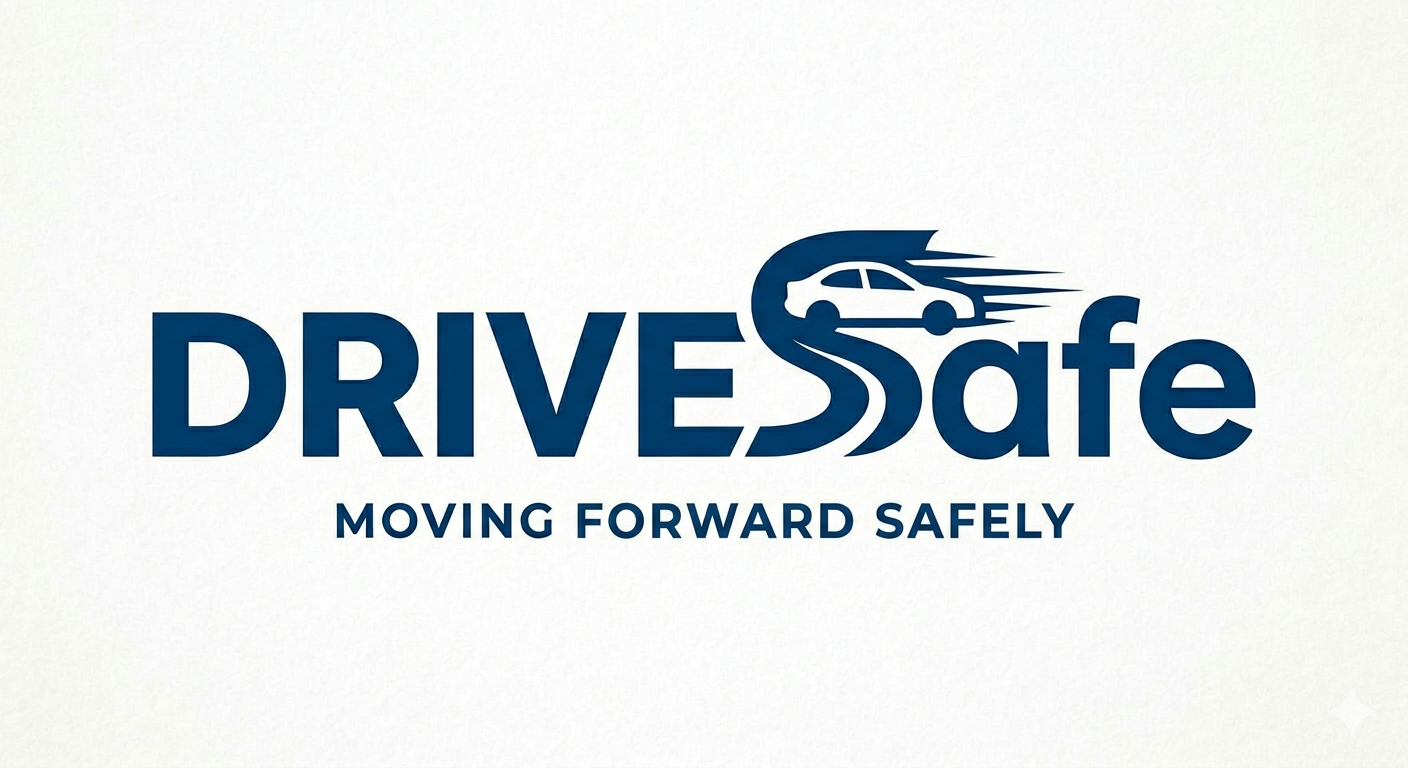

# 1. Understand the Problem

DriveSafe needs a deep learning model that can
accurately classify traffic signs from road images and
assign it to the correct traffic sign category.

This is an **image classification** problem because the
model must examine an image and assign it to the correct
traffic sign category.

Deep learning (especially Convolutional Neural Networks
(CNNs), is well-suited for image classification tasks
because CNNs can automatically learn visual patterns
such as edges, colors, shapes, and symbol structures
from image data.

# 2. Data Acquisition

## Data Source
This project will use a labeled traffic sign dataset.
The dataset includes:


*   image files of traffic signs
*   class labels for each image
*   CSV files such as 'Train.csv' and 'Test.csv' that
     help map images to their labels

In real world applications, data might also come from:


*   dashcams
*   public traffic datasets
*   transportation agencies
*   simulation environments

## Ethics Considerations

### 1. Safety & Nonmaleficence
If the model misclassifies a traffic sign, it could
potentially lead to a traffic accident

### 2. Fairness
The model should work equally well across all types of
lighting, weather, road conditions, and environment, not
only under ideal conditions.

### 3. Transparency & Explainability
It's important to understand the strengths and
limitations of the model so the developers know where the
system might fail.

### 4. Responsibility & Accountability
The company and developers are responsible for how the system
performs.

### 5. Privacy
Any data used in training should be obtained ethically and
any data including surrounding vehicles, pedestrians, or license
plates can be handled responsibly and with proper informed
consent.

### To uphold AI ethics in this project:
- use diverse and representative image data
- test the model on unseen data
- monitor for bias and uneven performance
- document limitations clearly
- use human oversight and safeguards

# 3. Data Exploration and Prep

## Step 1: Import Libraries

In [29]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Library for working with files and directory paths
import os

# Library for image processing
from PIL import Image

# Library for plotting and visualizing graphs
import matplotlib.pyplot as plt

# Sklearn function for splitting data into training and validation sets
from sklearn.model_selection import train_test_split

# Keras / Tensorflow utilities for deep learning
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## Step 2: Read the CSV file

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [31]:
import os

path = "/kaggle/input/gtsrb-german-traffic-sign"

print(os.listdir(path))

['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [32]:
train_df = pd.read_csv(f"{path}/Train.csv")
test_df = pd.read_csv(f"{path}/Test.csv")
meta_df = pd.read_csv(f"{path}/Meta.csv")

train_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [33]:
print(train_df.columns)
print(train_df.shape)

Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='object')
(39209, 8)


## Step 3: Load and Preprocess Images

We will:
- Load each image using the file path from the CSV
- Resize all images to a consistent size (30x30)
- Convert images into numerical arrays
- Store images and labels for training the model

This is necessary because neural networks require structured numerical input.

In [34]:
import numpy as np
from PIL import Image
data = []
labels = []

IMG_SIZE = (30, 30)

for i in range(len(train_df)):
  try:
    img_path = train_df.loc[i, 'Path']
    img = Image.open(img_path)
    img = img.resize(IMG_SIZE)
    img_array = np.array(img)

    data.append(img_array)
    labels.append(train_df.loc[i, 'ClassId'])

  except Exception as e:
    print(f"Error loading image at index {i}: {e}")

In [35]:
# Convert to arrays

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (39209, 30, 30, 3)
Labels shape: (39209,)


The dataset has been successfully converted into:
- "data": an array of image pixel values
- "labels": corresponding traffic sign classes

These'll be used as inputs and outputs for training the CNN model.

## Step 4: Normalize and Prepare Data

Before training the model, we'll:
- Normalize pixel values to a range of 0-1
- Split the dataset into training and validation sets
- Convert labels into one hot encoded format

This improves the model's performance and ensures the data is in a format suitable for deep learning.

In [36]:
# Normalize the data
data = data / 255.0

# Pixel values are 0-255
# Nueral networks learn better with values between 0-1

In [37]:
# Train/Validation Split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
    )
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

# stratify=labels keeps class balance
# 80% training, 20% validation

X_train: (31367, 30, 30, 3)
X_val: (7842, 30, 30, 3)


In [38]:
# One-hot encode labels

from tensorflow.keras.utils import to_categorical

num_classes = len(set(labels))
print("Number of classes:", num_classes)

y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

# Converts labels like 20 -> [0,0,0,....,1,...,0]
# required for multi class classification

Number of classes: 43
y_train shape: (31367, 43)
y_val shape: (7842, 43)


Images were normalized to improve training stability
The dataset was split into training and validation sets
Labels were one-hot encoded for multi class classification

The data is now ready to be used in a Convolutional Neural Network (CNN).

## Step 5: Build the Convolutional Neural Network (CNN)

We'll create a CNN to classify traffic sign images.
CNNs are well suited for image classification because they automatically learn spatial features like edges, shapes, and textures.

The model will include:
- Convolutional layers for feature extraction
- Pooling layers to reduce dimensionality
- Dropout layers to prevent overfitting
- Fully connected layers for classification

In [39]:
# Build the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolutional Block
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu', input_shape=(X_train.shape[1:])))
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

# Second Convolutional Block
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

# Flatten + Dense Layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(num_classes, activation='softmax'))

In [40]:
# View the model

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 22, 22, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,251 (946.29 KB)

 Trainable params: 242,251 (946.29 KB)

 Non-trainable params: 0 (0.00 B)

## Model Summary
The model consists of multiple convolutional layers to extract image features, followed by pooling and dropout layers to reduce overfitting.

The final dense layer uses a softmax activation function to classify images into one of 43 traffic sign categories.

In [41]:
# Compile the model
from tensorflow.keras.optimizers import Adam

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
    )

## Model Compilation

- Loss Function: Categorical Crossentropy -> used for multi class classification
- Optimizer: Adam -> efficient and widely used
- Metric: Accuracy -> to measure model performance

In [ ]:
# Train the Model
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=15,
    validation_data=(X_val, y_val)
    )

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 148s 147ms/step - accuracy: 0.6220 - loss: 1.3452 - val_accuracy: 0.9643 - val_loss: 0.1596
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 185s 130ms/step - accuracy: 0.9298 - loss: 0.2334 - val_accuracy: 0.9861 - val_loss: 0.0601
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 121s 123ms/step - accuracy: 0.9579 - loss: 0.1402 - val_accuracy: 0.9884 - val_loss: 0.0487
Epoch 4/15
923/981 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.9653 - loss: 0.1235

## Step 6: Evaluate the Training Process

Now that the CNN model has finished training, we'll evaluate how well it learned over time.

We'll look at:
- training accuracy
- validation accuracy
- training loss
- validation loss

This helps us determine whether the model is learning properly or showing signs of overfitting

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], color='green', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Accuracy Plot Interpretation
This graph compares the model's training accuracy and validation accuracy across each epoch.

If both lines increase and stay close together, the model is learning well and generalizing to validation data.

If training accuracy keeps increasing while validation accuracy drops or stays much lower, that may indicate overfitting.

The training and validation accuracy trends suggest that the model is learning well and generalizing effectively.

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], color='green', label='Training Loss')
plt.plot(history.history['val_loss'], color='blue', label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Loss Plot Interpretation
This graph compares training loss and  validation loss across each epoch.

Loss measures how far the model's predictions are from the correct answers. A decreasing loss usually means the model is improving.

If validation loss begins to increase while training loss continues to decrease, that may suggest overfitting.

In [ ]:
# Evaluate final model performance on validation data
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

## Validation Evaluation Summary

The validation results show how well the model performs on data it did not directly train on.

A high validation accuracy suggests that the learned meaningful visual patterns from the traffic sign images and can generalize beyond the training set

## Step 7: Evaluate Model on Test Data

To further evaluate the model, we'll test it on a separate dataset ('Test.csv') that was not used during training or validation.

This provides an unbiased estimate of how the model performs on new, unseen data.

In [ ]:
# Load test data images

test_images = []
test_labels = []

for i in range(len(test_df)):
  try:
    img_path = test_df.loc[i, 'Path']
    img = Image.open(img_path)
    img = img.resize((30, 30))
    img = np.array(img)

    test_images.append(img)
    test_labels.append(test_df.loc[i, 'ClassId'])

  except Exception as e:
    print(f"Error loading image at index {i}: {e}")

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print("Test images shape:", test_images.shape)

In [ ]:
# Normalize test data
test_images = test_images / 255.0

In [ ]:
# One-hot encode test labels
test_labels = to_categorical(test_labels, num_classes)

In [ ]:
# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

## Test Evaluation

The model was evaluated on a completely unseen dataset.

The test accuracy represents the model's real performance in practical application.

A high test accuracy indicates that the model has learned meaningful patterns and can generalize well beyond the training and validation data.

In [ ]:
# Show predictions
import random

index = random.randint(0, len(test_images)-1)
plt.imshow(test_images[index])
plt.title(f"True: {np.argmax(test_labels[index])}")
plt.axis('off')

prediction = model.predict(test_images[index].reshape(1, 30, 30, 3))
plt.title(f"Predicted: {np.argmax(prediction)}")
plt.show()


## Sample Prediction Visualization

The image shows a randomly selected traffic sign from the test dataset

- The **true label** represents the correct class
- The **predicted label** is the model's output

If both values match, the model has correctly classified the image.

This helps visually confirm the model's performance on unseen data.

## Final Conclusion

In this project, we successfully built and trained a Convolutional Neural Network (CNN) to classify traffic sign images.

Key achievements:
- Loaded and preprocessed a large real world dataset
- Achieved high accuracy on training, validation and test datasets
- Demonstrated the model's ability to generalize unseen data

This project highlights the effectiveness of deep learning techniques in computer vision tasks like traffic sign recognition.